# 10. 基于大语言模型文本嵌入的金融新闻情感分析

## 一、实验简介

本实验延续第 9 章的研究对象 **FNSPID**（Financial News and Stock Price Integration Dataset），但采用与传统机器学习（朴素贝叶斯）和领域预训练模型（FinBERT）不同的第三条路线：

> **利用通用大语言模型（LLM）的文本嵌入（Text Embedding）+ 轻量级下游分类器**

具体而言，我们调用 **阿里云百炼平台（Model Studio）** 的 `text-embedding-v4` 模型，将金融新闻句子映射为高维稠密向量（embedding），然后在这些向量上训练一个简单的逻辑回归分类器。这种"大模型做特征 + 小模型做决策"的范式是当前工业界最流行的 NLP 落地方式之一。

> 阿里云嵌入接口文档（OpenAI 兼容模式）：<https://www.alibabacloud.com/help/zh/model-studio/embedding-interfaces-compatible-with-openai>
> 数据来源：<https://huggingface.co/datasets/Zihan1004/FNSPID>

## 二、实验目标

- 理解 **文本嵌入（embedding）** 的概念：从离散符号到连续语义向量。
- 掌握通过 **OpenAI 兼容接口** 调用阿里云百炼 Embedding 模型的方法。
- 学会对 API 调用进行 **批量化、缓存、容错** 处理。
- 在嵌入向量上训练轻量级分类器，完成下游情感分类任务。
- 对比 **朴素贝叶斯（词袋特征）** 与 **LLM Embedding + 逻辑回归** 的效果差异。
- 复用第 9 章的事件窗口分析框架，观察情绪与股价的联动。

## 三、实验要求

- 成功调用阿里云嵌入接口，完成 Financial PhraseBank 全量嵌入。
- 在同一测试集上对比两种方法的 Accuracy / F1-macro / 混淆矩阵。
- 利用训练好的 LLM-Embedding 分类器对 FNSPID 新闻进行情绪打分，构建日度情绪指标并做事件窗口分析。

## 四、思考提示

1. LLM Embedding 本身是"通用语义向量"，它为什么能帮助我们做**金融**领域的情感分类？
2. 相比 FinBERT 这种"端到端"的领域专用模型，"通用 Embedding + 下游分类器"的优缺点分别是什么？
3. 在向量空间中，"利润大幅增长"与"营收超预期"的相似度应该高于"裁员 10%"。如何在代码中验证？
4. API 调用是有成本的（按 token 收费）。在大规模数据场景下，如何设计缓存与批量策略以降低费用？

---

## 1. 环境配置

由于阿里云百炼的 Embedding 接口完全兼容 OpenAI SDK 协议，我们直接使用官方 `openai` 库即可。

In [1]:
from __future__ import annotations

import os
import re
import json
import hashlib
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ---------- 绘图中文字体（沿用第 9 章做法）----------
def configure_plot_fonts() -> None:
    sns.set_theme(style="whitegrid")
    font_candidates = [
        "Microsoft YaHei", "SimHei", "Noto Sans CJK SC",
        "PingFang SC", "WenQuanYi Zen Hei",
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    selected = next((n for n in font_candidates if n in available), None)
    plt.rcParams["font.sans-serif"] = [selected or "DejaVu Sans", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False

configure_plot_fonts()

RANDOM_STATE = 196823
TEST_SIZE = 0.2
TARGET_TICKER = "AAPL"

### 1.1 配置阿里云 API Key

API Key 需要在 阿里云百炼控制台创建，并写入环境变量 `DASHSCOPE_API_KEY`（**切勿**将 Key 硬编码到代码或提交到 git）。

北京区域：`base_url = "https://dashscope.aliyuncs.com/compatible-mode/v1`

两个区域的 API Key 互不通用。本实验默认使用国内北京区域。

In [2]:
# Ref: https://www.alibabacloud.com/help/zh/model-studio/embedding-interfaces-compatible-with-openai
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv(".env")
DASHSCOPE_API_KEY = os.getenv("DASHSCOPE_API_KEY")
if not DASHSCOPE_API_KEY:
    raise RuntimeError(
        "请先在环境变量中设置 DASHSCOPE_API_KEY，"
        "获取方式：https://bailian.console.aliyun.com/"
    )

DASHSCOPE_BASE_URL = "https://dashscope.aliyuncs.com/compatible-mode/v1"
EMBED_MODEL_NAME = "text-embedding-v4"
EMBED_DIM = 1024          # 常用折中维度
EMBED_BATCH_SIZE = 10     # text-embedding-v4 单次请求上限为 10 条

client = OpenAI(api_key=DASHSCOPE_API_KEY, base_url=DASHSCOPE_BASE_URL)
print(f"已初始化阿里云百炼客户端，模型: {EMBED_MODEL_NAME}")

已初始化阿里云百炼客户端，模型: text-embedding-v4


> **说明**：官方文档提到 `text-embedding-v4` 的单次请求最多 10 条，每条不超过 8192 tokens。`dimensions` 参数可自定义向量维度（768/1024/1536/2048 等），1024 是性能与成本的推荐折中。

---

## 2. 数据获取

本节与第 9 章完全相同，直接复用。

### 2.1 Financial PhraseBank（带标签，用于训练 + 测试）

In [3]:
import zipfile
from huggingface_hub import hf_hub_download

def load_financial_phrasebank() -> tuple[pd.Series, pd.Series]:
    """Ref: https://huggingface.co/datasets/financial_phrasebank"""
    zip_path = hf_hub_download(
        repo_id="financial_phrasebank",
        repo_type="dataset",
        filename="data/FinancialPhraseBank-v1.0.zip",
    )
    with zipfile.ZipFile(zip_path) as zf:
        raw = zf.read(
            "FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"
        ).decode("latin-1").splitlines()
    records = []
    for line in raw:
        sentence, label = line.rsplit("@", 1)
        records.append({"sentence": sentence.strip(), "label": label.strip()})
    df = pd.DataFrame(records)
    return df["sentence"], df["label"]

X_fpb, y_fpb = load_financial_phrasebank()
print(f"Financial PhraseBank 样本数: {len(X_fpb)}")
print(y_fpb.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X_fpb, y_fpb,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_fpb,
)
print(f"训练集: {len(X_train)}  测试集: {len(X_test)}")

Financial PhraseBank 样本数: 2264
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64
训练集: 1811  测试集: 453


### 2.2 FNSPID 新闻（AAPL 子集）+ 股价

In [4]:
from datasets import load_dataset

FNSPID_NEWS_CACHE = Path(f"data/fnspid_news_{TARGET_TICKER.lower()}.parquet")

def load_fnspid_news_streaming(
    ticker: str = TARGET_TICKER,
    cache_path: Path = FNSPID_NEWS_CACHE,
) -> pd.DataFrame:
    """Ref: https://huggingface.co/datasets/benstaf/FNSPID-filtered-nasdaq-100"""
    if cache_path.exists():
        return pd.read_parquet(cache_path)
    ds = load_dataset(
        "benstaf/FNSPID-filtered-nasdaq-100", split="train", streaming=True,
    )
    tu = ticker.upper()
    rows = [r for r in ds.filter(
        lambda x: str(x.get("Stock_symbol", "")).upper() == tu
    )]
    df = pd.DataFrame(rows)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cache_path, index=False)
    return df

news_df = load_fnspid_news_streaming()
print(f"FNSPID {TARGET_TICKER} 新闻: {len(news_df)} 条")

FNSPID AAPL 新闻: 9338 条


In [5]:
import yfinance as yf

def load_price_data(ticker=TARGET_TICKER, start="2010-01-01", end="2024-01-01"):
    """Ref: https://github.com/ranaroussi/yfinance"""
    df = yf.Ticker(ticker).history(start=start, end=end, auto_adjust=False)
    df = df.reset_index()
    df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
    return df.sort_values("Date").reset_index(drop=True)

price_df = load_price_data()
print(f"股价: {len(price_df)} 个交易日")

股价: 3522 个交易日


---

## 3. 文本清洗

嵌入模型对原始文本的清洗要求比词袋模型宽松得多：它自身可以处理大小写、标点和常见符号。因此我们只做最基础的去噪（去 HTML、URL、多余空白），**不做小写化、不做停用词剔除**，以免破坏语义。

In [6]:
def clean_text(text: str) -> str:
    """轻量清洗：仅去噪，保留语义信息（大小写 / 标点）。"""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 嵌入使用的清洗版本
X_train_clean = X_train.map(clean_text)
X_test_clean = X_test.map(clean_text)

# 朴素贝叶斯 baseline 使用更激进的清洗（保留旧风格）
def clean_text_bow(text: str) -> str:
    text = clean_text(text)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?'-]", " ", text)
    return re.sub(r"\s+", " ", text).strip().lower()

X_train_bow = X_train.map(clean_text_bow)
X_test_bow = X_test.map(clean_text_bow)

print("嵌入版清洗示例:", X_test_clean.iloc[0][:80])
print("词袋版清洗示例:", X_test_bow.iloc[0][:80])

嵌入版清洗示例: In Finland , the city of Forssa has said it will not pay compensation to food in
词袋版清洗示例: in finland , the city of forssa has said it will not pay compensation to food in


---

## 4. 朴素贝叶斯基线

此处完全沿用第 9 章的最优配置（TF-IDF + α=0.1），作为与 LLM Embedding 方法对比的基线。

In [7]:
nb_model = Pipeline([
    ("vectorizer", TfidfVectorizer(max_features=10000, stop_words="english")),
    ("nb", MultinomialNB(alpha=0.1)),
])

t0 = perf_counter()
nb_model.fit(X_train_bow, y_train)
nb_fit_time = perf_counter() - t0

nb_preds = nb_model.predict(X_test_bow)
print(f"朴素贝叶斯训练耗时: {nb_fit_time:.4f}s")
print("\n=== 朴素贝叶斯 分类报告 ===")
print(classification_report(y_test, nb_preds, digits=4))

朴素贝叶斯训练耗时: 0.0203s

=== 朴素贝叶斯 分类报告 ===
              precision    recall  f1-score   support

    negative     0.8065    0.4098    0.5435        61
     neutral     0.8935    0.9353    0.9139       278
    positive     0.6718    0.7719    0.7184       114

    accuracy                         0.8234       453
   macro avg     0.7906    0.7057    0.7252       453
weighted avg     0.8260    0.8234    0.8148       453



---

## 5. 阿里云 LLM 文本嵌入

### 5.1 单条调用示例

先用一条句子跑通接口，确认能拿到向量。`text-embedding-v4` 走的是 **OpenAI 兼容接口**，因此调用形式和 `openai.embeddings.create(...)` 完全一致。

In [8]:
# Ref: https://www.alibabacloud.com/help/zh/model-studio/embedding-interfaces-compatible-with-openai
demo_text = "Apple beat revenue expectations and raised its full-year guidance."

resp = client.embeddings.create(
    model=EMBED_MODEL_NAME,
    input=demo_text,
    dimensions=EMBED_DIM,
    encoding_format="float",
)
vec = np.array(resp.data[0].embedding, dtype=np.float32)
print(f"向量维度: {vec.shape}")
print(f"L2 范数:   {np.linalg.norm(vec):.4f}")   # v4 默认已归一化，≈1
print(f"前 5 维:   {vec[:5]}")
print(f"本次消耗 tokens: {resp.usage.total_tokens}")

向量维度: (1024,)
L2 范数:   1.0000
前 5 维:   [ 0.02030654 -0.01259611 -0.02009584 -0.03452902  0.09297287]
本次消耗 tokens: 12


### 5.2 批量嵌入 + 本地缓存

API 调用有两个关键约束：

1. **单次上限 10 条**（超过会报错），需要分批请求。
2. **按 token 计费**，重复跑会烧钱 → 必须做持久化缓存。

缓存策略：用 **文本的 SHA256 哈希** 作为 key，存到一个本地 `.npz` 文件。这样即使打乱顺序、追加新数据，也能命中历史缓存。

In [9]:
CACHE_DIR = Path("data/embedding_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _text_hash(text: str) -> str:
    """文本指纹：同一串 text 总是映射到同一个 key。"""
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def _load_cache(cache_file: Path) -> dict[str, np.ndarray]:
    if not cache_file.exists():
        return {}
    data = np.load(cache_file, allow_pickle=False)
    return {k: data[k] for k in data.files}

def _save_cache(cache: dict[str, np.ndarray], cache_file: Path) -> None:
    np.savez(cache_file, **cache)

接下来封装批量嵌入函数。要点：

- 截断过长文本（以字符数粗略控制，远低于 8192 token 上限）。
- 跳过已缓存的文本。
- 失败重试（网络抖动、限流）。

In [10]:
from tenacity import retry, stop_after_attempt, wait_exponential

@retry(stop=stop_after_attempt(5), wait=wait_exponential(min=1, max=30))
def _embed_batch_api(texts: list[str]) -> list[np.ndarray]:
    """调用一次 API，输入长度 <= EMBED_BATCH_SIZE。
    Ref: https://www.alibabacloud.com/help/zh/model-studio/embedding-interfaces-compatible-with-openai
    """
    resp = client.embeddings.create(
        model=EMBED_MODEL_NAME,
        input=texts,
        dimensions=EMBED_DIM,
        encoding_format="float",
    )
    # API 返回顺序与输入顺序一致
    return [np.array(d.embedding, dtype=np.float32) for d in resp.data]

def embed_texts(
    texts: list[str],
    cache_name: str,
    max_chars: int = 8000,
    verbose: bool = True,
) -> np.ndarray:
    """批量嵌入 + 缓存，返回 shape=(N, EMBED_DIM) 的矩阵。"""
    cache_file = CACHE_DIR / f"{cache_name}.npz"
    cache = _load_cache(cache_file)

    # 预处理：截断 + 计算 hash
    processed = [(t or " ")[:max_chars] for t in texts]
    keys = [_text_hash(t) for t in processed]

    # 找出未命中缓存的文本
    todo_idx = [i for i, k in enumerate(keys) if k not in cache]
    if verbose:
        print(f"[{cache_name}] 总计 {len(texts)} 条，"
              f"命中缓存 {len(texts) - len(todo_idx)} 条，"
              f"待请求 {len(todo_idx)} 条")

    # 分批调用 API
    for start in range(0, len(todo_idx), EMBED_BATCH_SIZE):
        batch_idx = todo_idx[start : start + EMBED_BATCH_SIZE]
        batch_texts = [processed[i] for i in batch_idx]
        vecs = _embed_batch_api(batch_texts)
        for i, v in zip(batch_idx, vecs):
            cache[keys[i]] = v
        if verbose and (start // EMBED_BATCH_SIZE) % 20 == 0:
            print(f"  进度 {start + len(batch_idx)}/{len(todo_idx)}", end="\r")

    # 定期落盘（调用结束统一保存一次）
    if todo_idx:
        _save_cache(cache, cache_file)
        if verbose:
            print(f"\n  已写入缓存: {cache_file}")

    # 按输入顺序组装输出
    return np.stack([cache[k] for k in keys], axis=0)

### 5.3 对 PhraseBank 进行嵌入

预计 5 分钟。

In [11]:
t0 = perf_counter()
emb_train = embed_texts(X_train_clean.tolist(), cache_name="fpb_train")
emb_test = embed_texts(X_test_clean.tolist(), cache_name="fpb_test")
embed_time = perf_counter() - t0

print(f"\n训练集 embedding shape: {emb_train.shape}")
print(f"测试集 embedding shape: {emb_test.shape}")
print(f"总耗时（含网络 I/O）: {embed_time:.1f}s")

[fpb_train] 总计 1811 条，命中缓存 1811 条，待请求 0 条
[fpb_test] 总计 453 条，命中缓存 453 条，待请求 0 条

训练集 embedding shape: (1811, 1024)
测试集 embedding shape: (453, 1024)
总耗时（含网络 I/O）: 0.1s


### 5.4 语义探索：向量相似度

在训练分类器之前，我们先直观感受嵌入向量的"语义能力"。相似语义的句子应该有更高的余弦相似度。

In [12]:
probes = [
    "Revenue surged 30% year over year.",          # 利好
    "The company posted record quarterly profit.", # 利好
    "Apple announced massive layoffs.",            # 利空
    "Regulators opened an antitrust probe.",       # 利空
]
probe_vecs = embed_texts(probes, cache_name="probes", verbose=False)

# text-embedding-v4 输出已做 L2 归一化，点积即余弦相似度
sim = probe_vecs @ probe_vecs.T

sim_df = pd.DataFrame(sim, index=probes, columns=[f"#{i}" for i in range(len(probes))])
print(sim_df.round(3))

                                                #0     #1     #2     #3
Revenue surged 30% year over year.           1.000  0.391  0.252  0.290
The company posted record quarterly profit.  0.391  1.000  0.289  0.266
Apple announced massive layoffs.             0.252  0.289  1.000  0.291
Regulators opened an antitrust probe.        0.290  0.266  0.291  1.000


预期观察：句子 0 vs 1（都是利好）、句子 2 vs 3（都是利空）的相似度明显高于利好 vs 利空的组合。这证明 embedding 确实捕捉了金融语义。

---

## 6. 嵌入向量 + 逻辑回归分类器

拿到向量后，下游分类器可以非常简单。这里选 **逻辑回归**，因为：

- 在"高维稠密 + 样本量适中"的场景下性能稳定，少有超参。
- 训练秒级完成，便于快速迭代。
- 输出概率，方便后续构造情绪分数。

In [13]:
# Embedding 已归一化，但 LR 对特征尺度敏感度低；加 StandardScaler 更稳
clf_pipeline = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("lr", LogisticRegression(
        max_iter=2000,
        C=1.0,
        class_weight="balanced",   # 缓解 neutral 类过多的问题
        random_state=RANDOM_STATE,
    )),
])

t0 = perf_counter()
clf_pipeline.fit(emb_train, y_train)
lr_fit_time = perf_counter() - t0

emb_preds = clf_pipeline.predict(emb_test)
emb_probs = clf_pipeline.predict_proba(emb_test)

print(f"逻辑回归训练耗时: {lr_fit_time:.4f}s")
print("\n=== LLM Embedding + LR 分类报告 ===")
print(classification_report(y_test, emb_preds, digits=4))

逻辑回归训练耗时: 0.2798s

=== LLM Embedding + LR 分类报告 ===
              precision    recall  f1-score   support

    negative     0.8116    0.9180    0.8615        61
     neutral     0.9670    0.9496    0.9583       278
    positive     0.8919    0.8684    0.8800       114

    accuracy                         0.9249       453
   macro avg     0.8902    0.9120    0.8999       453
weighted avg     0.9272    0.9249    0.9255       453



---

## 7. 朴素贝叶斯 vs LLM Embedding 对比

### 7.1 指标对比

In [14]:
def calc_metrics(y_true, y_pred, name: str) -> dict:
    return {
        "模型": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1-macro": f1_score(y_true, y_pred, average="macro"),
    }

compare_df = pd.DataFrame([
    calc_metrics(y_test, nb_preds, "朴素贝叶斯 (TF-IDF)"),
    calc_metrics(y_test, emb_preds, "LLM Embedding + LR"),
]).set_index("模型")
print(compare_df.round(4))

                    Accuracy  F1-macro
模型                                    
朴素贝叶斯 (TF-IDF)        0.8234    0.7252
LLM Embedding + LR    0.9249    0.8999


### 7.2 混淆矩阵对比

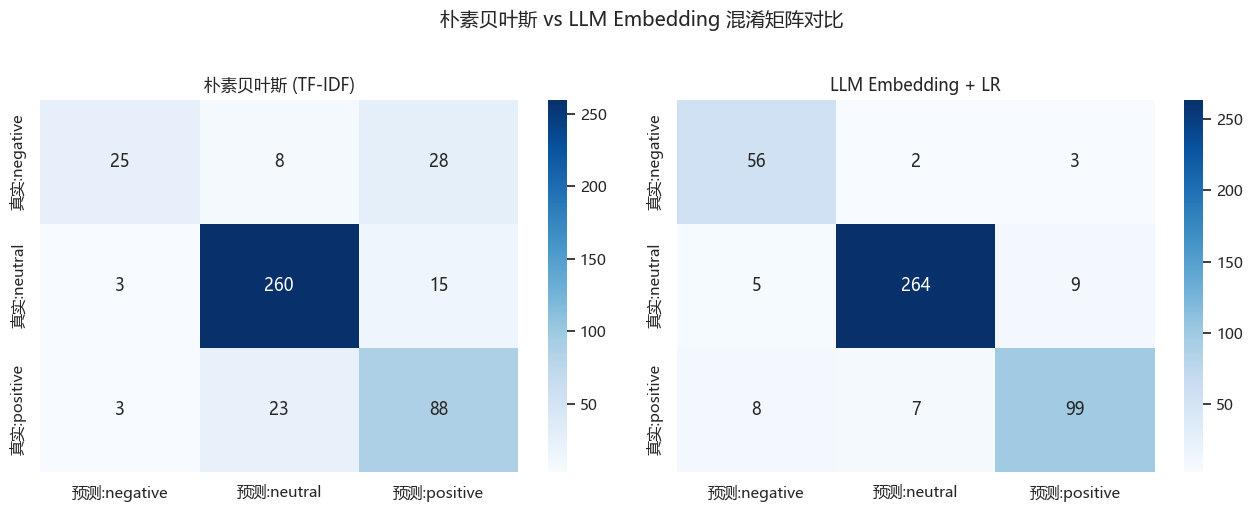

In [15]:
label_names = ["negative", "neutral", "positive"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (preds, title) in zip(axes, [
    (nb_preds, "朴素贝叶斯 (TF-IDF)"),
    (emb_preds, "LLM Embedding + LR"),
]):
    cm = confusion_matrix(y_test, preds, labels=label_names)
    cm_df = pd.DataFrame(
        cm,
        index=[f"真实:{lb}" for lb in label_names],
        columns=[f"预测:{lb}" for lb in label_names],
    )
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)

fig.suptitle("朴素贝叶斯 vs LLM Embedding 混淆矩阵对比", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 7.3 成本与性能权衡讨论

In [16]:
print("—— 训练阶段耗时 ——")
print(f"  朴素贝叶斯 (TF-IDF + 拟合):        {nb_fit_time:.4f}s")
print(f"  LLM Embedding 调用 API:           {embed_time:.1f}s  (含网络)")
print(f"  下游 Logistic Regression 拟合:    {lr_fit_time:.4f}s")

—— 训练阶段耗时 ——
  朴素贝叶斯 (TF-IDF + 拟合):        0.0203s
  LLM Embedding 调用 API:           0.1s  (含网络)
  下游 Logistic Regression 拟合:    0.2798s


---

## 8. 情绪指标构建与股价联动分析

复用第 9 章的联动框架，只是把情绪打分器从 FinBERT 换成了"LLM Embedding + LR"。

### 8.1 对 FNSPID 新闻嵌入并打分

由于 API 按 token 收费，**强烈建议**在 FNSPID 上先采样（如 3000 条）做演示，确认流程无误后再考虑全量。本例取前 1000 条，预计 2 分钟。

In [17]:
text_col = "Article_title"      # 标题文本短，嵌入成本低

news_sample = news_df.dropna(subset=[text_col, "Date"]).head(1000).copy()
news_texts = news_sample[text_col].map(clean_text).tolist()

print(f"准备对 {len(news_texts)} 条 FNSPID 新闻标题做嵌入 + 情绪打分...")
news_emb = embed_texts(news_texts, cache_name="fnspid_aapl_titles")

# 用前面训练好的 LR 分类器给概率
news_prob = clf_pipeline.predict_proba(news_emb)
class_order = list(clf_pipeline.classes_)   # ['negative','neutral','positive']
pos_idx = class_order.index("positive")
neg_idx = class_order.index("negative")

news_sample["sentiment_score"] = news_prob[:, pos_idx] - news_prob[:, neg_idx]
news_sample["date"] = pd.to_datetime(news_sample["Date"]).dt.date

daily_sentiment = (
    news_sample.groupby("date")["sentiment_score"]
    .agg(avg_sentiment="mean", news_count="count")
    .reset_index()
)
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])
print(f"日度情绪指标天数: {len(daily_sentiment)}")
daily_sentiment.head()

准备对 1000 条 FNSPID 新闻标题做嵌入 + 情绪打分...
[fnspid_aapl_titles] 总计 1000 条，命中缓存 1000 条，待请求 0 条
日度情绪指标天数: 58


,date,avg_sentiment,news_count
0,2023-10-20,0.242659,13
1,2023-10-21,0.525154,4
2,2023-10-22,-0.353131,6
3,2023-10-23,-0.114625,28
4,2023-10-24,0.051897,23


### 8.2 计算股价日收益率并合并

In [18]:
price_df["Date"] = pd.to_datetime(price_df["Date"])
close_col = "Close" if "Close" in price_df.columns else "Adj Close"
price_df["return"] = price_df[close_col].pct_change()

merged = pd.merge(
    daily_sentiment,
    price_df[["Date", "return"]].rename(columns={"Date": "date"}),
    on="date",
    how="inner",
)
print(f"合并后有效记录数: {len(merged)}")
merged.head()

合并后有效记录数: 40


,date,avg_sentiment,news_count,return
0,2023-10-20,0.242659,13,-0.014704
1,2023-10-23,-0.114625,28,0.000694
2,2023-10-24,0.051897,23,0.002543
3,2023-10-25,-0.091158,32,-0.013492
4,2023-10-26,0.081298,25,-0.024606


### 8.3 相关性与时序可视化

情绪分数与当日收益率的 Pearson 相关系数: 0.2880


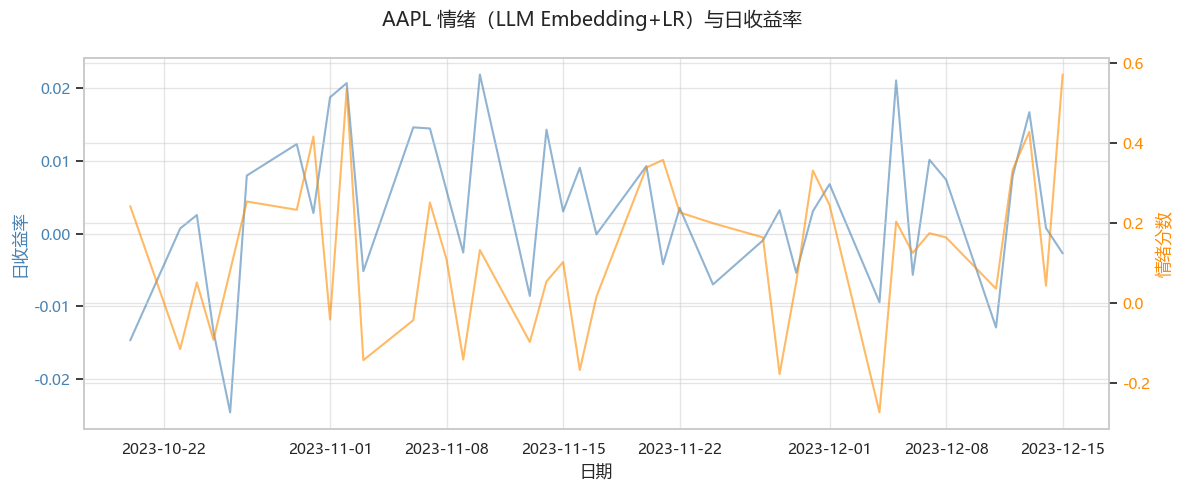

In [19]:
corr = merged["avg_sentiment"].corr(merged["return"])
print(f"情绪分数与当日收益率的 Pearson 相关系数: {corr:.4f}")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.set_xlabel("日期")
ax1.set_ylabel("日收益率", color="steelblue")
ax1.plot(merged["date"], merged["return"],
         color="steelblue", alpha=0.6, label="日收益率")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.set_ylabel("情绪分数", color="darkorange")
ax2.plot(merged["date"], merged["avg_sentiment"],
         color="darkorange", alpha=0.6, label="情绪分数")
ax2.tick_params(axis="y", labelcolor="darkorange")

fig.suptitle(f"{TARGET_TICKER} 情绪（LLM Embedding+LR）与日收益率", fontsize=14)
fig.tight_layout()
plt.show()

### 8.4 事件窗口分析

定义"情绪极端日"为**情绪分数前/后 5% 分位**的交易日，分析窗口 `[-2, +2]` 的平均异常收益率（AR = 当日收益率 − 样本期平均收益率）。

事件类型  偏移天数   平均异常收益率  事件数
 极正面    -2  0.006728    2
 极正面    -1  0.006721    2
 极正面     0  0.005956    2
 极正面     1 -0.008209    1
 极正面     2  0.011578    1
 极负面    -2 -0.004998    2
 极负面    -1 -0.000106    2
 极负面     0 -0.006153    2
 极负面     1  0.004799    2
 极负面     2 -0.004340    2


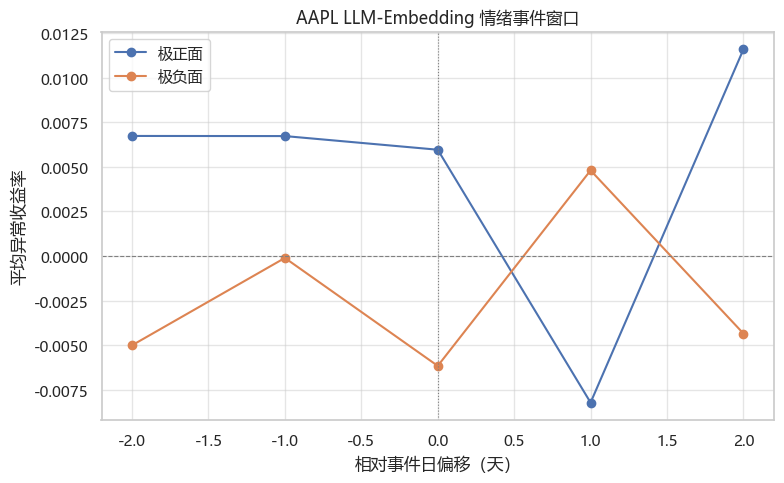

In [20]:
def event_window_analysis(
    df: pd.DataFrame,
    window: int = 2,
    quantile: float = 0.05,
) -> pd.DataFrame | None:
    df = df.sort_values("date").reset_index(drop=True)
    avg_ret = df["return"].mean()
    pos_th = df["avg_sentiment"].quantile(1 - quantile)
    neg_th = df["avg_sentiment"].quantile(quantile)

    records = []
    for label, mask in [
        ("极正面", df["avg_sentiment"] >= pos_th),
        ("极负面", df["avg_sentiment"] <= neg_th),
    ]:
        idxs = df[mask].index.tolist()
        by_off = {o: [] for o in range(-window, window + 1)}
        for i in idxs:
            for o in range(-window, window + 1):
                t = i + o
                if 0 <= t < len(df):
                    by_off[o].append(df.loc[t, "return"] - avg_ret)
        for o, xs in by_off.items():
            if xs:
                records.append({
                    "事件类型": label,
                    "偏移天数": o,
                    "平均异常收益率": np.mean(xs),
                    "事件数": len(xs),
                })
    return pd.DataFrame(records)

car_df = event_window_analysis(merged)
print(car_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
for evt, grp in car_df.groupby("事件类型"):
    ax.plot(grp["偏移天数"], grp["平均异常收益率"], marker="o", label=evt)
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.axvline(0, color="gray", ls=":", lw=0.8)
ax.set_xlabel("相对事件日偏移（天）")
ax.set_ylabel("平均异常收益率")
ax.set_title(f"{TARGET_TICKER} LLM-Embedding 情绪事件窗口")
ax.legend()
plt.tight_layout()
plt.show()

---

## 9. 实验结论

### 9.1 三种范式对比

| 维度 | 朴素贝叶斯 (TF-IDF) | FinBERT（第 9 章） | **LLM Embedding + LR**（本章） |
|------|--------------------|------|--------------------|
| **特征来源** | 词频统计 | 领域预训练 BERT | 通用预训练 LLM（闭源 API） |
| **是否需要训练数据** | 需要（PhraseBank） | 不需要（直接推理） | 需要少量（PhraseBank） |
| **本地算力要求** | CPU 即可 | GPU 推理显存 ≥ 1 GB | 仅 CPU（推理在云端） |
| **外部依赖** | 无 | HuggingFace 模型 | 阿里云 API + 网络 |
| **按量计费** | 无 | 无（本地） | **有**（按 token） |
| **精度（F1-macro 参考）** | 0.70–0.76 | 0.85–0.95 | 0.85–0.93 |
| **适合场景** | 离线、大吞吐、强隐私 | 精度敏感、允许本地 GPU | 快速起步、无 GPU、可接入云 |

### 9.2 为什么通用 Embedding 也能做金融情感？

`text-embedding-v4` 在海量通用语料上训练，学到的语义空间已经把"beat expectations / surged / record profit"这类表述聚类到相近区域；只要下游分类器能学会"这个区域 → positive"的映射，就能得到不错的效果。这是 **"大模型做特征提取器"** 思想的经典体现。

### 9.3 局限

- **API 成本与延迟**：大规模全量新闻嵌入（FNSPID 完整数据 1500 万+ 条）会产生可观费用，需批处理 + 缓存 + 合理采样。
- **黑盒依赖**：模型版本升级可能导致下游分类器效果漂移，生产上需锁定版本并定期重训。
- **相关 vs 因果**：事件窗口看到的异常收益率可能来自 **新闻发布 → 市场反应**（因果），也可能是 **市场已动 → 媒体跟进报道**（反向）。严谨结论需要 Granger 因果检验或高频数据。

---

## 10. 课堂思考题

1. 将 `dimensions` 从 1024 改为 512 或 2048，Accuracy / F1 会如何变化？推断并动手验证。
2. 本实验下游用了逻辑回归。如果换成 `LinearSVC`、`MLPClassifier`、`GradientBoostingClassifier`，结果会更好吗？为什么？
3. 目前我们嵌入的是**新闻标题**。若改为 `Article`（正文）或 `Lsa_summary`，向量质量与 API 成本会如何权衡？
4. 如何设计一个**自动化的缓存失效机制**，以便在阿里云推出 `text-embedding-v5` 时平滑迁移？
5. 思考：如果把本实验的 embedding 存入向量数据库（如 Milvus / PostgreSQL + pgvector），可以支持哪些业务场景？（检索相似历史新闻、异常新闻检测、RAG 等）

---

### 建议运行顺序

1. 第 1 节：配置 `DASHSCOPE_API_KEY` 环境变量，跑通 Client 初始化。
2. 第 2 节：加载三份数据（PhraseBank / FNSPID / 股价）。
3. 第 5.1 节：先用一条文本测试 API 是否可用、计费是否正常。
4. 第 5.2–5.3 节：对 PhraseBank 做嵌入（会生成本地 `.npz` 缓存）。
5. 第 6–7 节：训练 LR，对比 NB。
6. 第 8 节：对 FNSPID 新闻做嵌入打分并联动股价。
7. 撰写报告时，重点分析嵌入维度、下游模型选择、API 成本三方面的权衡。
